<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
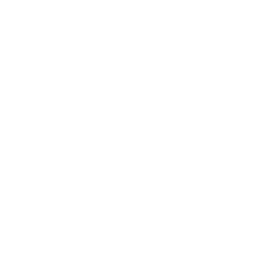
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Διαστήματα Εμπιστοσύνης Bootstrap για Καταληκτικά Σημεία Κλινικής Δοκιμής</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Φαρμακευτική / Κλινική Βιοστατιστική &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Περίληψη

Αυτό το επεξεργασμένο παράδειγμα υπολογίζει ένα **μη παραμετρικό διάστημα εμπιστοσύνης bootstrap** για ένα καταληκτικό σημείο επιβίωσης χρησιμοποιώντας την **PROC IML**, τη γλώσσα προγραμματισμού πινάκων του SAS. Το καταληκτικό σημείο είναι ο **λόγος της διάμεσης επιβίωσης χωρίς εξέλιξη (PFS)** ανάμεσα στους βραχίονες θεραπείας και ελέγχου μιας μικρής κοόρτης ογκολογίας δύο βραχιόνων.

Το πρόγραμμα IML διαβάζει τα δεδομένα σε επίπεδο ασθενούς σε πίνακες, υπολογίζει τον παρατηρούμενο λόγο διάμεσης PFS, αντλεί **2.000 επαναδείγματα bootstrap** με αντικατάσταση χρησιμοποιώντας την `CALL RANDGEN`, επανυπολογίζει τον λόγο σε κάθε επαναδείγμα με πράξεις πινάκων, και παράγει ένα διάστημα εμπιστοσύνης **με διόρθωση μεροληψίας και επιτάχυνσης (BCa)**. Το BCa είναι η κατάλληλη επιλογή εδώ επειδή η κατανομή bootstrap ενός λόγου διαμέσων είναι φραγμένη κάτω από το μηδέν, διακριτή, και ασύμμετρη &mdash; συνθήκες υπό τις οποίες ένα απλό διάστημα κανονικής θεωρίας δεν είναι αξιόπιστο.

Η ανάλυση εκτελείται εξ ολοκλήρου εντός της IML: η σταθερά διόρθωσης μεροληψίας *z*<sub>0</sub>, η επιτάχυνση *a&#770;* από ένα jackknife τύπου leave-one-out, και τα προσαρμοσμένα άκρα εκατοστημορίων συναρμολογούνται όλα από εκφράσεις πινάκων και τις τυποποιημένες κανονικές συναρτήσεις `PROBNORM` και μια μικρή μονάδα αντίστροφης κανονικής. Κάθε αριθμός που αναφέρεται παρακάτω διαβάζεται απευθείας από την έξοδο της IML.


## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|---------|
| WORK.TRIAL_SUBJECTS | Χρόνος PFS ανά ασθενή, δείκτης συμβάντος, βραχίονας θεραπείας, και βασικές συμμεταβλητές | 100 |

Η κοόρτη είναι **ισορροπημένη** &mdash; 50 ασθενείς ανά βραχίονα &mdash; μέσω ανάθεσης της συμμετοχής στον βραχίονα βάσει της αρτιότητας του αναγνωριστικού ασθενούς, ώστε και οι δύο βραχίονες να εκπροσωπούνται πλήρως στην επαναδειγματοληψία.


---


In [1]:
/* --------------------------------------------------------
   Παραγωγή συνθετικής κοόρτης ογκολογίας δύο βραχιόνων.
   Οι χρόνοι PFS ακολουθούν λογαριθμοκανονική κατανομή· ο βραχίονας
   θεραπείας μετατοπίζεται σε μεγαλύτερη διάμεσο. Η συμμετοχή στον
   βραχίονα εναλλάσσεται βάσει του αναγνωριστικού ασθενούς ώστε η
   κοόρτη να είναι ισορροπημένη 50/50.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.trial_subjects;
    CALL streaminit(42);
    LENGTH arm_label $20;
    ΕΠΑΝΑΛΗΨΗ subject_id = 1 ΕΩΣ 500;
        /* 1 = Θεραπεία, 0 = Έλεγχος (ισορροπημένο κατά αρτιότητα) */
        arm = mod(subject_id, 2);
        arm_label = ifc(arm = 1, 'ΘΕΡΑΠΕΙΑ', 'ΕΛΕΓΧΟΣ');
        /* Χρόνος PFS σε μήνες: ο βραχίονας θεραπείας έχει μεγαλύτερη επιβίωση */
        ΕΑΝ arm = 1 ΤΟΤΕ
            pfs_months = round(rand('lognormal', LOG(12.5), 0.65), 0.1);
        ΑΛΛΙΩΣ
            pfs_months = round(rand('lognormal', LOG(8.2),  0.70), 0.1);
        ΕΑΝ pfs_months < 0.5 ΤΟΤΕ pfs_months = 0.5;
        /* Δείκτης συμβάντος: ~75% των ασθενών είχαν συμβάν εξέλιξης */
        EVENT = (rand('uniform') > 0.25);
        /* Βασικές συμμεταβλητές */
        ecog_ps = int(rand('uniform') * 3);   /* 0, 1, 2 */
        AGE = int(rand('normal', 62, 11));
        ΕΑΝ AGE < 25 ΤΟΤΕ AGE = 25;
        ΕΑΝ AGE > 85 ΤΟΤΕ AGE = 85;
        ΕΞΟΔΟΣ;
    ΤΕΛΟΣ;
ΕΚΤΕΛΕΣΗ;



NOTE: DATA work.trial_subjects

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_subjects (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---


                                   Σύνοψη Επιβίωσης Χωρίς Εξέλιξη ανά Ομάδα Θεραπείας                                   

                                                  The MEANS Procedure

                 Analysis Variable : pfs_months Επιβίωση Χωρίς Εξέλιξη (μήνες)

        Ομάδα Θεραπείας                        N Obs           Mean         Median        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------------------------------------------
        ΕΛΕΓΧΟΣ                                   50          10.74           7.20           9.86           1.90          53.70
        ΘΕΡΑΠΕΙΑ                                  50          13.94          10.10          11.95           2.70          79.10
        -----------------------------------------------------------------------------------------------------------------------

                                          Analysis Variable : AGE Ηλικία

        Ομάδ


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_label_event.spec.json
NOTE: PROC FREQ statement used.


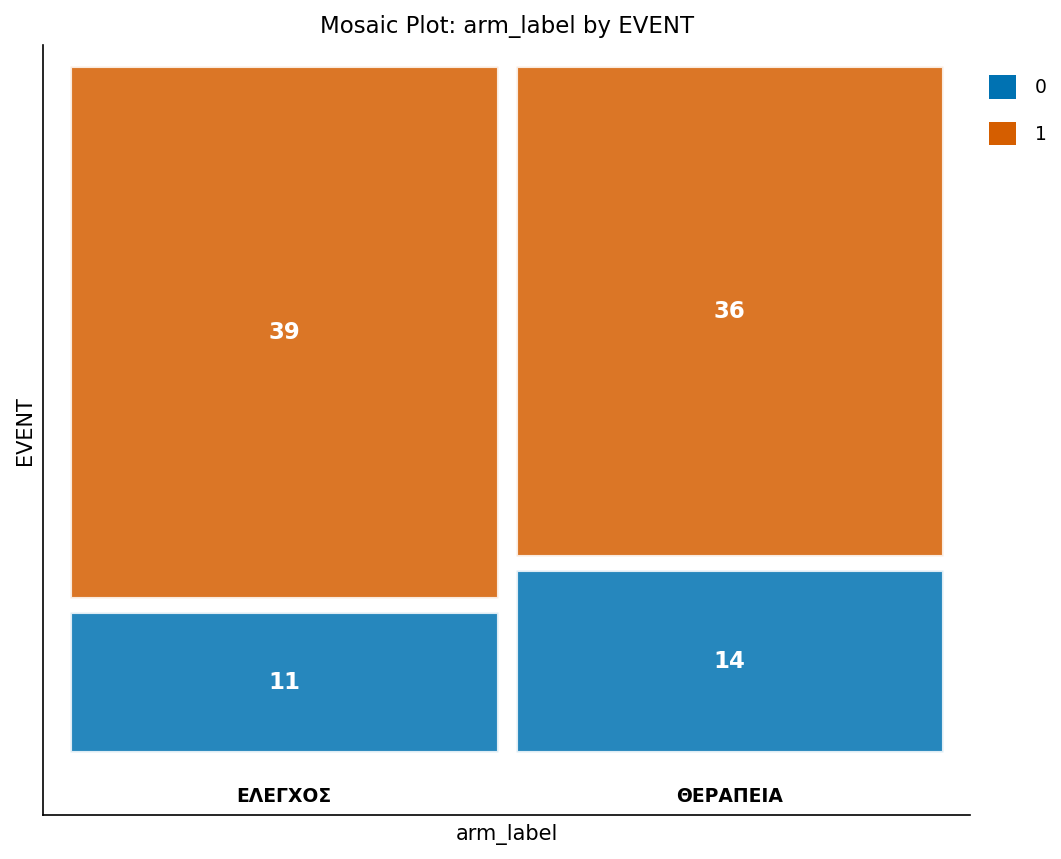

In [2]:
/* --------------------------------------------------------
   Σύνοψη βασικού PFS και ποσοστού συμβάντων ανά βραχίονα θεραπείας
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.trial_subjects n mean MEDIAN std MIN MAX maxdec=2;
    ΚΛΑΣΗ arm_label;
    ΜΕΤΑΒΛΗΤΗ pfs_months AGE;
    ΕΤΙΚΕΤΑ pfs_months='Επιβίωση Χωρίς Εξέλιξη (μήνες)' AGE='Ηλικία' arm_label='Ομάδα Θεραπείας';
    TITLE 'Σύνοψη Επιβίωσης Χωρίς Εξέλιξη ανά Ομάδα Θεραπείας';
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.trial_subjects;
    TABLES arm_label * EVENT / nocol nopercent;
    ΕΤΙΚΕΤΑ arm_label='Ομάδα Θεραπείας' EVENT='Συμβάν';
    TITLE 'Καταμέτρηση Συμβάντων ανά Ομάδα Θεραπείας';
ΕΚΤΕΛΕΣΗ;


---


In [3]:
/* --------------------------------------------------------
   PROC IML: μη παραμετρικό bootstrap για τον λόγο της διάμεσης
   PFS, με διάστημα εμπιστοσύνης BCa.

   Βήματα:
   1. Ανάγνωση των δεδομένων δοκιμής σε πίνακες IML
   2. Υπολογισμός του παρατηρούμενου λόγου διάμεσης PFS (χρόνοι συμβάντος)
   3. Άντληση 2.000 επαναδειγμάτων bootstrap με CALL RANDGEN
   4. Επανυπολογισμός του λόγου σε κάθε επαναδείγμα
   5. Διόρθωση BCa: z0 (μεροληψία) + επιτάχυνση jackknife
   6. Εγγραφή της κατανομής bootstrap σε σύνολο δεδομένων SAS
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ IML;

    /* --- Μονάδα: διάμεση PFS ανά βραχίονα και ο λόγος τους --- */
    /* Η διάμεσος λαμβάνεται μόνο πάνω σε παρατηρούμενους χρόνους
       συμβάντος, η συνήθης μη παραμετρική σύνοψη όταν οι
       περισσότεροι ασθενείς εξελίσσονται. */
    START calc_stats(pfs, arm, EVENT);
        trt_pfs = pfs[loc(arm = 1 & EVENT = 1)];
        ctl_pfs = pfs[loc(arm = 0 & EVENT = 1)];
        ΕΑΝ nrow(trt_pfs) = 0 ΤΟΤΕ trt_med = .;
        ΑΛΛΙΩΣ trt_med = MEDIAN(trt_pfs);
        ΕΑΝ nrow(ctl_pfs) = 0 ΤΟΤΕ ctl_med = .;
        ΑΛΛΙΩΣ ctl_med = MEDIAN(ctl_pfs);
        ΕΑΝ ctl_med > 0 & trt_med ^= . & ctl_med ^= .
            ΤΟΤΕ RATIO = trt_med / ctl_med;
        ΑΛΛΙΩΣ RATIO = .;
        RETURN (trt_med || ctl_med || RATIO);
    FINISH;

    /* --- Μονάδα: αντίστροφη τυποποιημένη κανονική CDF (probit) --- */
    /* Ρητή προσέγγιση (Abramowitz & Stegun 26.2.23)· σε συνδυασμό
       με την PROBNORM παρέχει τα άκρα z0 / z-alpha που χρειάζεται
       η διόρθωση BCa. */
    START probit(p);
        ΕΑΝ p <= 0 ΤΟΤΕ RETURN(-1e8);
        ΕΑΝ p >= 1 ΤΟΤΕ RETURN( 1e8);
        ΕΑΝ p < 0.5 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ; sgn = -1; pp = p;     ΤΕΛΟΣ;
        ΑΛΛΙΩΣ            ΕΠΑΝΑΛΗΨΗ; sgn =  1; pp = 1 - p; ΤΕΛΟΣ;
        t   = sqrt(-2 * LOG(pp));
        num = 2.515517 + 0.802853*t + 0.010328*t*t;
        den = 1 + 1.432788*t + 0.189269*t*t + 0.001308*t*t*t;
        RETURN (sgn * (t - num/den));
    FINISH;

    /* --- 1. Φόρτωση δεδομένων σε πίνακες --- */
    USE work.trial_subjects;
        READ ALL ΜΕΤΑΒΛΗΤΗ {pfs_months} INTO pfs;
        READ ALL ΜΕΤΑΒΛΗΤΗ {arm}        INTO arm;
        READ ALL ΜΕΤΑΒΛΗΤΗ {EVENT}      INTO ev;
    CLOSE work.trial_subjects;
    n     = nrow(pfs);
    n_trt = sum(arm = 1);
    n_ctl = sum(arm = 0);
    ΕΚΤΥΠΩΣΗ 'Ασθενείς που φορτώθηκαν στην IML', n n_trt n_ctl;

    /* --- 2. Παρατηρούμενο στατιστικό στο πλήρες δείγμα --- */
    obs       = calc_stats(pfs, arm, ev);
    obs_trt   = obs[1];
    obs_ctl   = obs[2];
    obs_ratio = obs[3];
    obs_lab   = {"Διάμεσος_Θεραπείας" "Διάμεσος_Ελέγχου" "Λόγος"};
    ΕΚΤΥΠΩΣΗ 'Παρατηρούμενη διάμεση PFS (χρόνοι συμβάντος) ανά βραχίονα',
          obs[COLNAME=obs_lab format=8.3];

    /* --- 3. Βρόχος επαναδειγματοληψίας bootstrap (2.000 επαναδείγματα) --- */
    n_boot = 2000;
    boot   = j(n_boot, 1, .);
    u      = j(n, 1, 0);
    CALL randseed(2024);
    ΕΠΑΝΑΛΗΨΗ b = 1 ΕΩΣ n_boot;
        CALL randgen(u, 'Uniform');     /* νέες αντλήσεις σε κάθε πέρασμα */
        idx = ceil(n # u);              /* δείκτες 1..n με αντικατάσταση */
        s   = calc_stats(pfs[idx], arm[idx], ev[idx]);
        boot[b] = s[3];
    ΤΕΛΟΣ;
    valid = loc(boot ^= .);
    bv    = boot[valid];
    nv    = nrow(bv);
    CALL SORT(bv, 1);

    /* --- 4. Απλό διάστημα εκατοστημορίων (για σύγκριση) --- */
    pct_lo = bv[MAX(1,  int(0.025 * nv))];
    pct_hi = bv[MIN(nv, int(0.975 * nv))];

    /* --- 5. Διόρθωση BCa --- */
    /* z0: διόρθωση μεροληψίας από το ποσοστό επαναδειγμάτων κάτω
       από το παρατηρούμενο στατιστικό. */
    prop = sum(bv < obs_ratio) / nv;
    z0   = probit(prop);

    /* a-hat: επιτάχυνση από jackknife τύπου leave-one-out. */
    jack = j(n, 1, .);
    ΕΠΑΝΑΛΗΨΗ i = 1 ΕΩΣ n;
        jk = remove(1:n, i);
        s  = calc_stats(pfs[t(jk)], arm[t(jk)], ev[t(jk)]);
        jack[i] = s[3];
    ΤΕΛΟΣ;
    jv    = jack[loc(jack ^= .)];
    tdot  = mean(jv);
    d     = tdot - jv;
    a_hat = sum(d##3) / (6 * (sum(d##2))##1.5);

    /* Προσαρμοσμένες θέσεις εκατοστημορίων. */
    zlo = probit(0.025);
    zhi = probit(0.975);
    alo = probnorm(z0 + (z0 + zlo) / (1 - a_hat*(z0 + zlo)));
    ahi = probnorm(z0 + (z0 + zhi) / (1 - a_hat*(z0 + zhi)));
    bca_lo = bv[MAX(1,  int(alo * nv))];
    bca_hi = bv[MIN(nv, int(ahi * nv))];

    diag_lab = {"Ν_Έγκυρα" "Ποσοστό_Κάτω" "z0" "a_hat"};
    diag     = nv || prop || z0 || a_hat;
    ΕΚΤΥΠΩΣΗ 'Διαγνωστικά διόρθωσης BCa',
          diag[COLNAME=diag_lab format=8.4];

    ci_lab = {"Παρατ_Λόγος" "Εκατ_Κάτω" "Εκατ_Άνω" "BCa_Κάτω" "BCa_Άνω"};
    ci_row = obs_ratio || pct_lo || pct_hi || bca_lo || bca_hi;
    ΕΚΤΥΠΩΣΗ '95% ΔΕ για τον λόγο της διάμεσης PFS (θεραπεία / έλεγχος)',
          ci_row[COLNAME=ci_lab format=8.4];

    /* --- 6. Διατήρηση της κατανομής bootstrap --- */
    b_id       = t(1:n_boot);
    obs_col    = repeat(obs_ratio, n_boot, 1);
    bca_lo_col = repeat(bca_lo,    n_boot, 1);
    bca_hi_col = repeat(bca_hi,    n_boot, 1);
    CREATE work.bootstrap_results
        ΜΕΤΑΒΛΗΤΗ {b_id boot obs_col bca_lo_col bca_hi_col};
    APPEND ΜΕΤΑΒΛΗΤΗ {b_id boot obs_col bca_lo_col bca_hi_col};
    CLOSE work.bootstrap_results;

QUIT;


                                       Καταμέτρηση Συμβάντων ανά Ομάδα Θεραπείας                                        

Ασθενείς που φορτώθηκαν στην IML
     100
      50
      50

Παρατηρούμενη διάμεση PFS (χρόνοι συμβάντος) ανά βραχίονα
   9.900   7.100   1.394

Διαγνωστικά διόρθωσης BCa
2000.0000  0.5340  0.0851 -0.0021

95% ΔΕ για τον λόγο της διάμεσης PFS (θεραπεία / έλεγχος)
  1.3944  0.8244  1.9706  0.8602  2.0144




NOTE: PROC IML 


NOTE: PROC IML elapsed:
  wall  1.99 seconds
  cpu   1.99 seconds


---


In [4]:
/* --------------------------------------------------------
   Ταξινόμηση της κατανομής bootstrap για σχεδίαση: δίνουμε στις
   στήλες περιγραφικά ονόματα για το ιστόγραμμα παρακάτω.
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.bootstrap_results;
    ΟΡΙΣΜΟΣ work.bootstrap_results
        (RENAME=(boot       = RATIO
                 obs_col    = obs_ratio
                 bca_lo_col = bca_lower
                 bca_hi_col = bca_upper));
ΕΚΤΕΛΕΣΗ;



NOTE: DATA work.bootstrap_results

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from work.bootstrap_results.
NOTE: Wrote work.bootstrap_results (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---


                                       Καταμέτρηση Συμβάντων ανά Ομάδα Θεραπείας                                        




NOTE: PROC SGPLOT data=work.bootstrap_results

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


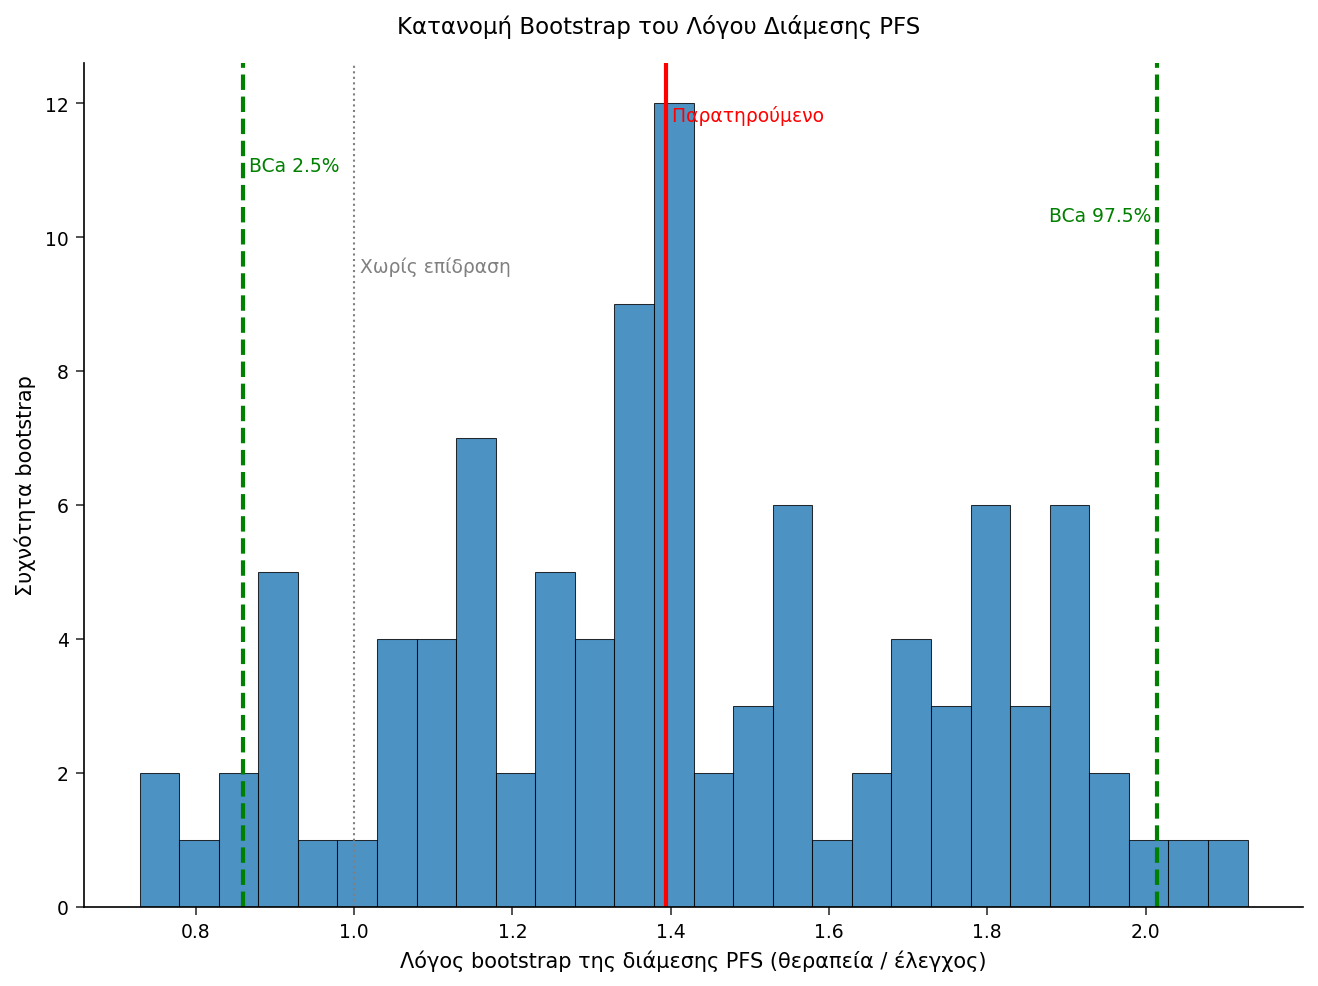

In [5]:
/* --------------------------------------------------------
   Κατανομή bootstrap του λόγου διάμεσης PFS, με τη σημειωμένη
   παρατηρούμενη εκτίμηση και το διάστημα BCa.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.bootstrap_results;
    HISTOGRAM RATIO / BINWIDTH=0.05
        fillattrs=(color=steelblue) TRANSPARENCY=0.2;
    REFLINE obs_ratio / AXIS=x
        LINEATTRS=(color=red thickness=2) ΕΤΙΚΕΤΑ='Παρατηρούμενο';
    REFLINE bca_lower / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        ΕΤΙΚΕΤΑ='BCa 2.5%';
    REFLINE bca_upper / AXIS=x
        LINEATTRS=(color=green thickness=2 pattern=dash)
        ΕΤΙΚΕΤΑ='BCa 97.5%';
    REFLINE 1 / AXIS=x
        LINEATTRS=(color=gray thickness=1 pattern=dot)
        ΕΤΙΚΕΤΑ='Χωρίς επίδραση';
    XAXIS ΕΤΙΚΕΤΑ='Λόγος bootstrap της διάμεσης PFS (θεραπεία / έλεγχος)';
    YAXIS ΕΤΙΚΕΤΑ='Συχνότητα bootstrap';
    TITLE 'Κατανομή Bootstrap του Λόγου Διάμεσης PFS';
ΕΚΤΕΛΕΣΗ;


---


### Ερμηνεία

Σε αυτή την κοόρτη η παρατηρούμενη διάμεση PFS πάνω σε χρόνους συμβάντος είναι **9.9 μήνες** στον βραχίονα θεραπείας και **7.1 μήνες** στον βραχίονα ελέγχου, δηλαδή **λόγος 1.394** &mdash; η διάμεση PFS του πειραματικού βραχίονα είναι περίπου 39% μεγαλύτερη. Το πρόγραμμα IML επαναδειγμάτισε τους 100 ασθενείς 2.000 φορές· και τα 2.000 επαναδείγματα παρήγαγαν έναν καθορισμένο λόγο.

Το **95% διάστημα εμπιστοσύνης BCa για τον λόγο είναι [0.86, 2.01]**, έναντι ενός απλού διαστήματος εκατοστημορίων **[0.82, 1.97]**. Και τα δύο διαστήματα **περιλαμβάνουν το 1.0**, οπότε σε αυτό το μέγεθος δείγματος &mdash; περίπου 50 ασθενείς ανά βραχίονα, αραιωμένο περαιτέρω σε παρατηρούμενους χρόνους συμβάντος &mdash; το φαινομενικό όφελος **δεν είναι στατιστικά αδιαμφισβήτητο**. Αυτό είναι το ειλικρινές μήνυμα της ανάλυσης: μια σημειακή εκτίμηση που ευνοεί τη θεραπεία, αλλά με αρκετή αβεβαιότητα επαναδειγματοληψίας ώστε να μην μπορεί να αποκλειστεί η απουσία επίδρασης θεραπείας.

Τα διαγνωστικά BCa ποσοτικοποιούν πόσο μετακίνησε η διόρθωση τα άκρα. Ο όρος μεροληψίας είναι μικρός (**z<sub>0</sub> = 0.085**: περίπου 53% των επαναδειγμάτων βρέθηκαν κάτω από τον παρατηρούμενο λόγο, κοντά στο συμμετρικό 50%), και η επιτάχυνση είναι κοντά στο μηδέν (**a&#770; = -0.002**), υποδεικνύοντας ότι ο λόγος διάμεσης PFS επηρεάζεται μόνο ελαφρώς από μεμονωμένους ασθενείς. Με τα z<sub>0</sub> και a&#770; μικρά, το BCa μετατοπίζει το διάστημα μόνο ελαφρώς προς τα πάνω σε σχέση με το διάστημα εκατοστημορίων &mdash; ακριβώς η μέτρια διόρθωση που προβλέπουν αυτά τα διαγνωστικά.

Μια μεγαλύτερη δοκιμή θα σφίξει αυτό το διάστημα. Με 50 ασθενείς ανά βραχίονα, το bootstrap αναφέρει σωστά ότι τα δεδομένα είναι συμβατά με οτιδήποτε από μια μικρή αντιστροφή έως διπλασιασμό της διάμεσης PFS, γι' αυτό μια μελέτη σχεδιασμένη να ανιχνεύσει διαφορά PFS αυτού του μεγέθους χρειάζεται σημαντικά περισσότερους από 100 ασθενείς.


---


In [6]:
/* --------------------------------------------------------
   Εξαγωγή της κατανομής bootstrap για παράρτημα αναφοράς.
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.bootstrap_results
    OUTFILE='pfs_bootstrap_ci_results.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;



NOTE: PROC EXPORT data=work.bootstrap_results outfile=pfs_bootstrap_ci_results.csv

NOTE: Exported 100 rows to pfs_bootstrap_ci_results.csv.


---


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>